In [56]:
from pathlib import Path
import json, random
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

past_len = 10
future_len = 20
batch_size = 64
epochs = 30
lr = 1e-3
cnn_channels = 64
lstm_hidden = 128
lstm_layers = 1
dropout = 0.1

save_dir = Path.home() / "Documents/Thesis/models"
save_dir.mkdir(parents=True, exist_ok=True)
model_path = save_dir / "kitti_seq00_cnn_lstm_done.pt"
summary_path = save_dir / "summary_seq00_done.json"

print("Model path:", model_path)
print("Summary path:", summary_path)

DEVICE: cuda
Model path: /home/basudeo/Documents/Thesis/models/kitti_seq00_cnn_lstm_done.pt
Summary path: /home/basudeo/Documents/Thesis/models/summary_seq00_done.json


In [57]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [58]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [59]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [60]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [61]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [62]:
def evaluate_metrics(pred, true):
    dists = np.linalg.norm(pred - true, axis=2)
    ade = float(dists.mean())
    fde = float(dists[:, -1].mean())
    rmse = float(np.sqrt(((pred - true) ** 2).mean()))
    return ade, fde, rmse


def constant_velocity_predict(past, future_len):
    last = past[:, -1:, :]
    velocity = past[:, -1:, :] - past[:, -2:-1, :]
    steps = np.arange(1, future_len + 1, dtype=np.float32).reshape(1, future_len, 1)
    return last + velocity * steps


def evaluate_constant_velocity(loader, future_len):
    cv_pred = []
    cv_true = []

    for past, future in loader:
        past_np = past.numpy()
        future_np = future.numpy()
        cv_pred.append(constant_velocity_predict(past_np, future_len))
        cv_true.append(future_np)

    cv_pred = np.concatenate(cv_pred, axis=0)
    cv_true = np.concatenate(cv_true, axis=0)
    return evaluate_metrics(cv_pred, cv_true)


In [63]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [64]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [65]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [66]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [67]:
# Removed old single-sequence pipeline.
# Use the half-sequence pipeline below.


In [68]:
from pathlib import Path
import numpy as np
import pandas as pd

VEL_ROOT = Path("/media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences")
POSE_ROOT = Path("/media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences")
AVAILABLE_SEQS = sorted([
    p.name for p in VEL_ROOT.iterdir()
    if p.is_dir() and (POSE_ROOT / p.name / "poses.txt").exists()
])
seq_count = max(1, (len(AVAILABLE_SEQS) * 3 + 3) // 4)
SEQS = AVAILABLE_SEQS[:seq_count]
print("Available sequences:", AVAILABLE_SEQS)
print("Using sequences:", SEQS)

all_xy = []
all_rows = []

for seq in SEQS:
    seq_vel = Path(str(VEL_ROOT / seq / "velodyne"))
    seq_pose = Path(str(POSE_ROOT / seq / "poses.txt"))

    print(f"\nSequence {seq}")
    print("seq_vel exists:", seq_vel.exists(), seq_vel)
    print("seq_pose exists:", seq_pose.exists(), seq_pose)

    bin_files = sorted(seq_vel.glob("*.bin"))
    poses = np.loadtxt(str(seq_pose))

    print("num bin files:", len(bin_files))
    print("poses shape:", poses.shape)

    assert len(bin_files) == len(poses), f"Mismatch in sequence {seq}"

    xy = np.stack([poses[:, 3], poses[:, 7]], axis=1)
    all_xy.append(xy)

    seq_df = pd.DataFrame({
        "seq": seq,
        "frame_id": np.arange(len(xy)),
        "x": xy[:, 0],
        "y": xy[:, 1],
        "lidar_path": [str(p) for p in bin_files],
    })
    all_rows.append(seq_df)

xy = np.concatenate(all_xy, axis=0)
df = pd.concat(all_rows, ignore_index=True)

print("\nFinal xy shape:", xy.shape)
print("Total rows:", len(df))
print(df.head())
print(df.tail())

model_path = save_dir / "kitti_75pct_cnn_lstm_done.pt"
summary_path = save_dir / "summary_75pct_done.json"
print("Model path:", model_path)
print("Summary path:", summary_path)

Available sequences: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
Using sequences: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16']

Sequence 00
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/00/velodyne
seq_pose exists: True /media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences/00/poses.txt
num bin files: 4541
poses shape: (4541, 12)

Sequence 01
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/01/velodyne
seq_pose exists: True /media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences/01/poses.txt
num bin files: 1101
poses shape: (1101, 12)

Sequence 02
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/02/velodyne
seq_pose exists: True /media/basudeo/New Volume/Downlo

num bin files: 2761
poses shape: (2761, 12)

Sequence 06
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/06/velodyne
seq_pose exists: True /media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences/06/poses.txt
num bin files: 1101
poses shape: (1101, 12)

Sequence 07
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/07/velodyne
seq_pose exists: True /media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences/07/poses.txt
num bin files: 1101
poses shape: (1101, 12)

Sequence 08
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/08/velodyne
seq_pose exists: True /media/basudeo/New Volume/Download/data_odometry_labels/dataset/sequences/08/poses.txt
num bin files: 4071
poses shape: (4071, 12)

Sequence 09
seq_vel exists: True /media/basudeo/New Volume/Download/data_odometry_velodyne/dataset/sequences/09/velodyne
seq_pose 

In [69]:
from torch.utils.data import Dataset
import torch

class MultiSeqTrajDataset(Dataset):
    def __init__(self, df, past_len=10, future_len=20):
        self.past_len = past_len
        self.future_len = future_len
        self.samples = []

        for seq in sorted(df["seq"].unique()):
            seq_df = df[df["seq"] == seq].copy()
            xy = seq_df[["x", "y"]].values.astype(np.float32)

            total = len(xy)
            for i in range(total - past_len - future_len + 1):
                self.samples.append((seq, xy, i))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, xy, i = self.samples[idx]

        past = xy[i:i+self.past_len]
        future = xy[i+self.past_len:i+self.past_len+self.future_len]

        origin = past[-1].copy()
        past_rel = past - origin
        future_rel = future - origin

        return (
            torch.tensor(past_rel, dtype=torch.float32),
            torch.tensor(future_rel, dtype=torch.float32),
        )

dataset = MultiSeqTrajDataset(df, past_len=past_len, future_len=future_len)

print("samples:", len(dataset))

past0, future0 = dataset[0]
print("past shape:", past0.shape)
print("future shape:", future0.shape)
print("last past point:", past0[-1])
print("first future point:", future0[0])

samples: 32234
past shape: torch.Size([10, 2])
future shape: torch.Size([20, 2])
last past point: tensor([0., 0.])
first future point: tensor([-0.0325, -0.0173])


In [70]:
from torch.utils.data import DataLoader, Subset

n = len(dataset)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

train_set = Subset(dataset, list(range(0, n_train)))
val_set = Subset(dataset, list(range(n_train, n_train + n_val)))
test_set = Subset(dataset, list(range(n_train + n_val, n)))

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("train:", n_train)
print("val:", n_val)
print("test:", n_test)

train: 22563
val: 4835
test: 4836


In [71]:
class CNNLSTM(nn.Module):
    def __init__(self, past_len=10, future_len=20, cnn_channels=64, lstm_hidden=128, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.future_len = future_len

        self.cnn = nn.Sequential(
            nn.Conv1d(2, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, future_len * 2),
        )

    def forward(self, past_xy):
        # past_xy: [B, T, 2]
        x = past_xy.transpose(1, 2)   # [B, 2, T]
        x = self.cnn(x)               # [B, C, T]
        x = x.transpose(1, 2)         # [B, T, C]

        _, (h, _) = self.lstm(x)
        z = h[-1]

        out = self.head(z)
        return out.view(-1, self.future_len, 2)

model = CNNLSTM(past_len=past_len, future_len=future_len).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("num params:", sum(p.numel() for p in model.parameters()))
print(model)

num params: 133800
CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(64, 128, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=40, bias=True)
  )
)


In [72]:
def run_epoch(loader, train=True):
    model.train(train)
    total = 0.0
    count = 0

    for past, future in loader:
        past = past.to(DEVICE)
        future = future.to(DEVICE)

        pred = model(past)
        loss = criterion(pred, future)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total += loss.item() * past.size(0)
        count += past.size(0)

    return total / max(count, 1)


best_val = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, epochs + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:02d} | train={train_loss:.6f} | val={val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "cfg": {
                "past_len": past_len,
                "future_len": future_len,
                "cnn_channels": 64,
                "lstm_hidden": 128,
                "lstm_layers": 1,
                "dropout": 0.1,
            },
        }, model_path)

print("Best val:", best_val)
print("Saved best model to:", model_path)

Epoch 01 | train=4.274706 | val=0.787146
Epoch 02 | train=0.640242 | val=0.643434
Epoch 03 | train=0.530171 | val=0.513275
Epoch 04 | train=0.431558 | val=0.493194
Epoch 05 | train=0.326108 | val=0.322108
Epoch 06 | train=0.261094 | val=0.349380
Epoch 07 | train=0.243952 | val=0.248451
Epoch 08 | train=0.228815 | val=0.292814
Epoch 09 | train=0.221036 | val=0.311027
Epoch 10 | train=0.212589 | val=0.324533
Epoch 11 | train=0.209714 | val=0.297109
Epoch 12 | train=0.208630 | val=0.334230
Epoch 13 | train=0.203675 | val=0.263406
Epoch 14 | train=0.203285 | val=0.278802
Epoch 15 | train=0.195210 | val=0.314274
Epoch 16 | train=0.200479 | val=0.262516
Epoch 17 | train=0.194814 | val=0.269745
Epoch 18 | train=0.194237 | val=0.352124
Epoch 19 | train=0.202174 | val=0.265291
Epoch 20 | train=0.194572 | val=0.264720
Epoch 21 | train=0.191475 | val=0.264921
Epoch 22 | train=0.189468 | val=0.330519
Epoch 23 | train=0.190604 | val=0.271564
Epoch 24 | train=0.186926 | val=0.276630
Epoch 25 | train

In [73]:
ckpt = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_pred = []
all_true = []

with torch.no_grad():
    for past, future in test_loader:
        past = past.to(DEVICE)
        pred = model(past).cpu().numpy()
        all_pred.append(pred)
        all_true.append(future.numpy())

pred = np.concatenate(all_pred, axis=0)
true = np.concatenate(all_true, axis=0)

cv_pred = []
cv_true = []

for past, future in test_loader:
    past_np = past.numpy()
    future_np = future.numpy()
    cv_pred.append(constant_velocity_predict(past_np, future_len))
    cv_true.append(future_np)

cv_pred = np.concatenate(cv_pred, axis=0)
cv_true = np.concatenate(cv_true, axis=0)

cv_ade, cv_fde, cv_rmse = evaluate_metrics(cv_pred, cv_true)
ADE, FDE, RMSE = evaluate_metrics(pred, true)

summary = {
    "model": "cnn_lstm",
    "sequences": SEQS,
    "samples": len(dataset),
    "train": n_train,
    "val": n_val,
    "test": n_test,
    "ADE": ADE,
    "FDE": FDE,
    "RMSE": RMSE,
    "model_path": str(model_path),
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

comparison = {
    "constant_velocity": {
        "ADE": cv_ade,
        "FDE": cv_fde,
        "RMSE": cv_rmse,
    },
    "cnn_lstm": {
        "ADE": ADE,
        "FDE": FDE,
        "RMSE": RMSE,
    },
}

print(comparison)
print(summary)
print("Saved summary to:", summary_path)

{'constant_velocity': {'ADE': 0.5380911827087402, 'FDE': 1.4050830602645874, 'RMSE': 0.6749395728111267}, 'cnn_lstm': {'ADE': 0.3642473816871643, 'FDE': 0.9284042119979858, 'RMSE': 0.41545188426971436}}
{'model': 'cnn_lstm', 'sequences': ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16'], 'samples': 32234, 'train': 22563, 'val': 4835, 'test': 4836, 'ADE': 0.3642473816871643, 'FDE': 0.9284042119979858, 'RMSE': 0.41545188426971436, 'model_path': '/home/basudeo/Documents/Thesis/models/kitti_75pct_cnn_lstm_done.pt'}
Saved summary to: /home/basudeo/Documents/Thesis/models/summary_75pct_done.json


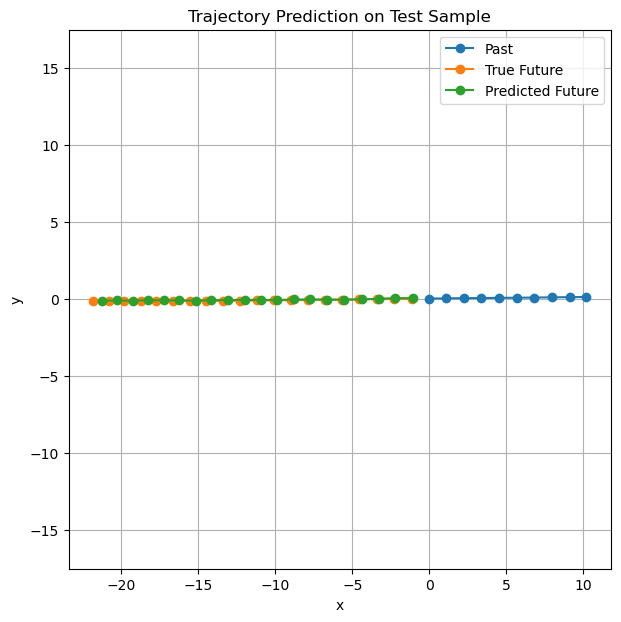

In [74]:
import matplotlib.pyplot as plt

# pick one test sample
past, future = test_set[0]

model.eval()
with torch.no_grad():
    pred = model(past.unsqueeze(0).to(DEVICE)).cpu().squeeze(0).numpy()

past = past.numpy()
future = future.numpy()

plt.figure(figsize=(7, 7))
plt.plot(past[:, 0], past[:, 1], marker='o', label='Past')
plt.plot(future[:, 0], future[:, 1], marker='o', label='True Future')
plt.plot(pred[:, 0], pred[:, 1], marker='o', label='Predicted Future')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory Prediction on Test Sample")
plt.axis("equal")
plt.grid(True)
plt.show()

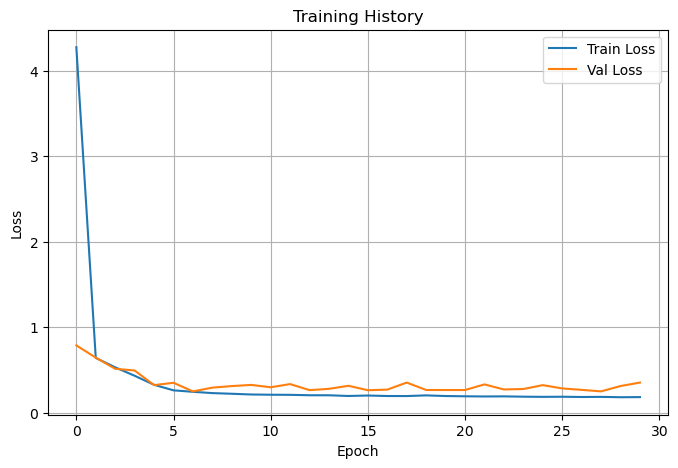

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

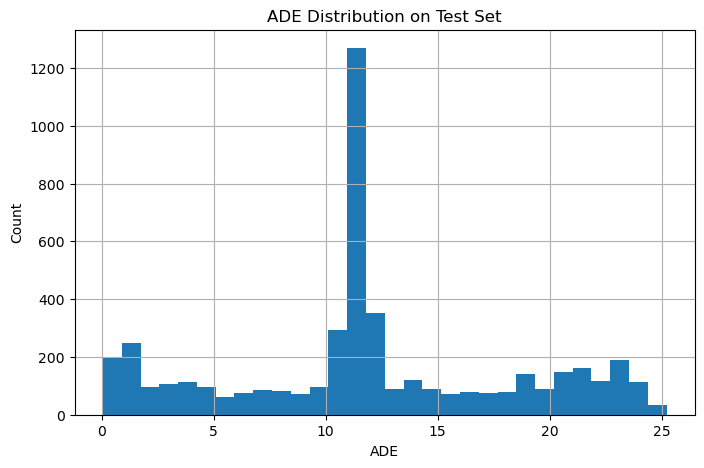

In [76]:
dists = np.linalg.norm(pred - true, axis=2)
sample_ade = dists.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(sample_ade, bins=30)
plt.xlabel("ADE")
plt.ylabel("Count")
plt.title("ADE Distribution on Test Set")
plt.grid(True)
plt.show()